Vehicle Insurance Claim Fraud Detection
URL- https://www.kaggle.com/datasets/shivamb/vehicle-claim-fraud-detection

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('fraud_oracle.csv')
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [3]:
df.shape

(15420, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [5]:
df.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='object')

In [6]:
df.isnull().sum()

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

In [7]:
df.isnull().sum().max()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['FraudFound_P'].value_counts()

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

In [10]:
df['FraudFound_P'].value_counts()/df.shape[0]*100

FraudFound_P
0    94.014267
1     5.985733
Name: count, dtype: float64

imbalance data

In [11]:
cat_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()


In [12]:
cat_cols

['Month',
 'DayOfWeek',
 'Make',
 'AccidentArea',
 'DayOfWeekClaimed',
 'MonthClaimed',
 'Sex',
 'MaritalStatus',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'VehiclePrice',
 'Days_Policy_Accident',
 'Days_Policy_Claim',
 'PastNumberOfClaims',
 'AgeOfVehicle',
 'AgeOfPolicyHolder',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'NumberOfSuppliments',
 'AddressChange_Claim',
 'NumberOfCars',
 'BasePolicy']

In [13]:
df['Make'].value_counts()


Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Dodge         109
Saab          108
Mercury        83
Saturn         58
Nisson         30
BMW            15
Jaguar          6
Porche          5
Mecedes         4
Ferrari         2
Lexus           1
Name: count, dtype: int64

In [14]:

df['Make'] = df['Make'].where(df.groupby('Make')['Make'].transform('count') > 1000, 'Other')


In [15]:
df['DayOfWeekClaimed'].value_counts()

DayOfWeekClaimed
Monday       3757
Tuesday      3375
Wednesday    2951
Thursday     2660
Friday       2497
Saturday      127
Sunday         52
0               1
Name: count, dtype: int64

In [16]:
df[df['DayOfWeekClaimed'] == '0'].index

Index([1516], dtype='int64')

In [17]:
df.drop(df[df['DayOfWeekClaimed'] == '0'].index, inplace=True)

In [18]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married     10625
Single       4683
Divorced       76
Widow          35
Name: count, dtype: int64

In [19]:
df['PolicyType'].value_counts()

PolicyType
Sedan - Collision       5584
Sedan - Liability       4987
Sedan - All Perils      4086
Sport - Collision        348
Utility - All Perils     340
Utility - Collision       30
Sport - All Perils        22
Utility - Liability       21
Sport - Liability          1
Name: count, dtype: int64

In [20]:
df['PolicyType'] = df['PolicyType'].str.split(' - ').str[1]

In [21]:
df['PolicyType'].value_counts()

PolicyType
Collision     5962
Liability     5009
All Perils    4448
Name: count, dtype: int64

In [22]:
df['VehicleCategory'].value_counts()

VehicleCategory
Sedan      9670
Sport      5358
Utility     391
Name: count, dtype: int64

In [23]:
df['VehiclePrice'].value_counts()

VehiclePrice
20000 to 29000     8079
30000 to 39000     3533
more than 69000    2163
less than 20000    1096
40000 to 59000      461
60000 to 69000       87
Name: count, dtype: int64

In [24]:
price_map = {
    'less than 20000': 15000,
    '20000 to 29000': 24500,
    '30000 to 39000': 34500,
    '40000 to 59000': 49500,
    '60000 to 69000': 64500,
    'more than 69000': 75000
}

df['Price_Numeric'] = df['VehiclePrice'].map(price_map)

df['Price_Numeric'].value_counts()

Price_Numeric
24500    8079
34500    3533
75000    2163
15000    1096
49500     461
64500      87
Name: count, dtype: int64

In [25]:
df['Price_Numeric'].dtypes

dtype('int64')

In [26]:
df['Days_Policy_Accident'].value_counts()/df.shape[0]*100

Days_Policy_Accident
more than 30    98.878008
none             0.356703
8 to 15          0.356703
15 to 30         0.317790
1 to 7           0.090797
Name: count, dtype: float64

In [27]:
df['Days_Policy_Accident'].value_counts().index

Index(['more than 30', 'none', '8 to 15', '15 to 30', '1 to 7'], dtype='object', name='Days_Policy_Accident')

In [28]:
map = {
    'more than 30':35, 'none':0, '8 to 15':11, '15 to 30':22, '1 to 7':5
}

df['Days_Policy_Accident'] = df['Days_Policy_Accident'].map(map)

In [29]:
df['Days_Policy_Claim'].value_counts()/df.shape[0]*100

Days_Policy_Claim
more than 30    99.500616
15 to 30         0.363188
8 to 15          0.136196
Name: count, dtype: float64

In [30]:
map = {
    'more than 30':35, '15 to 30':22, '8 to 15':11
}

df['Days_Policy_Claim'] = df['Days_Policy_Claim'].map(map)

In [31]:
df['PastNumberOfClaims'].value_counts()

PastNumberOfClaims
2 to 4         5485
none           4351
1              3573
more than 4    2010
Name: count, dtype: int64

In [32]:
map = {
    'none':0, '2 to 4':2, '1':1, 'more than 4':5
}

df['PastNumberOfClaims'] = df['PastNumberOfClaims'].map(map)

In [33]:
df['AgeOfVehicle'].value_counts()

AgeOfVehicle
7 years        5807
more than 7    3981
6 years        3448
5 years        1357
new             372
4 years         229
3 years         152
2 years          73
Name: count, dtype: int64

In [34]:
df['AgeOfVehicle'].replace('new', '0', inplace=True)

In [35]:
df['AgeOfVehicle'] = df['AgeOfVehicle'].str.extract('(\d+)').astype(int)

In [36]:
df['AgeOfVehicle'].value_counts()

AgeOfVehicle
7    9788
6    3448
5    1357
0     372
4     229
3     152
2      73
Name: count, dtype: int64

In [37]:
df['AgeOfPolicyHolder'].value_counts() # all ready have same column Age 

AgeOfPolicyHolder
31 to 35    5593
36 to 40    4043
41 to 50    2828
51 to 65    1392
26 to 30     613
over 65      508
16 to 17     319
21 to 25     108
18 to 20      15
Name: count, dtype: int64

In [38]:
df.drop('AgeOfPolicyHolder', axis=1, inplace=True)

In [39]:
df['PoliceReportFiled'].value_counts()/df.shape[0]*100

PoliceReportFiled
No     97.224204
Yes     2.775796
Name: count, dtype: float64

In [40]:
df['WitnessPresent'].value_counts()/df.shape[0]*100

WitnessPresent
No     99.435761
Yes     0.564239
Name: count, dtype: float64

In [41]:
df['AgentType'].value_counts()

AgentType
External    15178
Internal      241
Name: count, dtype: int64

In [42]:
df['NumberOfSuppliments'].value_counts()

NumberOfSuppliments
none           7046
more than 5    3867
1 to 2         2489
3 to 5         2017
Name: count, dtype: int64

In [43]:
map = {
    'none':0, '1 to 2':1, '3 to 5':3, 'more than 5':5
}

df['NumberOfSuppliments'] = df['NumberOfSuppliments'].map(map)

In [44]:
df['AddressChange_Claim'].value_counts()

AddressChange_Claim
no change         14323
4 to 8 years        631
2 to 3 years        291
1 year              170
under 6 months        4
Name: count, dtype: int64

In [45]:
df['NumberOfCars'].value_counts()

NumberOfCars
1 vehicle      14315
2 vehicles       709
3 to 4           372
5 to 8            21
more than 8        2
Name: count, dtype: int64

In [46]:
map = {
    '1 vehicle':1, '2 vehicles':2, '3 to 4':4, '5 to 8':8, 'more than 8':10
}

df['NumberOfCars'] = df['NumberOfCars'].map(map)

In [47]:
df['BasePolicy'].value_counts()

BasePolicy
Collision     5962
Liability     5009
All Perils    4448
Name: count, dtype: int64

In [48]:
df['PolicyType'].value_counts() # after preprocess

PolicyType
Collision     5962
Liability     5009
All Perils    4448
Name: count, dtype: int64

In [49]:
(df['PolicyType'] == df['BasePolicy']).value_counts()

True    15419
Name: count, dtype: int64

In [50]:
df.drop('BasePolicy', axis=1, inplace=True)

In [51]:
df.shape

(15419, 32)

In [52]:
cat_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [53]:
cat_cols

['Month',
 'DayOfWeek',
 'Make',
 'AccidentArea',
 'DayOfWeekClaimed',
 'MonthClaimed',
 'Sex',
 'MaritalStatus',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'VehiclePrice',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'AddressChange_Claim']

In [54]:
num_cols

['WeekOfMonth',
 'WeekOfMonthClaimed',
 'Age',
 'FraudFound_P',
 'PolicyNumber',
 'RepNumber',
 'Deductible',
 'DriverRating',
 'Days_Policy_Accident',
 'Days_Policy_Claim',
 'PastNumberOfClaims',
 'AgeOfVehicle',
 'NumberOfSuppliments',
 'NumberOfCars',
 'Year',
 'Price_Numeric']

In [55]:
df['Year'].value_counts()

Year
1994    6141
1995    5195
1996    4083
Name: count, dtype: int64

In [56]:
df.drop('Year', axis=1, inplace=True)

<Axes: ylabel='Frequency'>

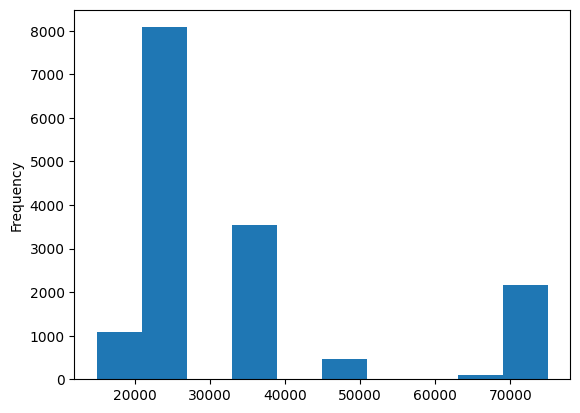

In [57]:
df['Price_Numeric'].plot(kind='hist')

In [58]:
df['DriverRating'].value_counts()/df.shape[0]*100

DriverRating
1    25.578831
3    25.189701
2    24.644919
4    24.586549
Name: count, dtype: float64

In [59]:
df['RepNumber'].value_counts() # RepNumber should be categorical it is id 

RepNumber
7     1069
9      999
5      987
1      987
10     986
12     977
15     976
16     967
2      956
3      949
11     948
6      942
14     941
8      931
4      912
13     892
Name: count, dtype: int64

In [60]:
df['RepNumber'] = df['RepNumber'].astype('category')


<Axes: ylabel='Frequency'>

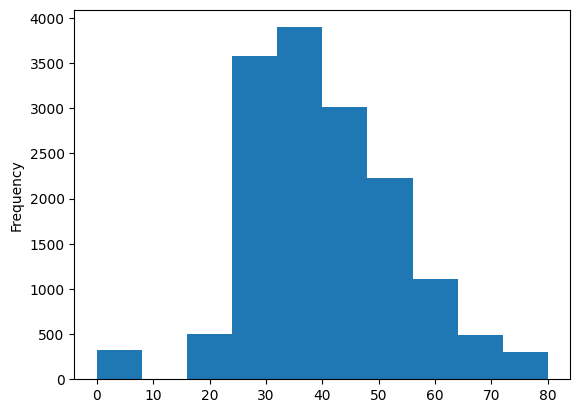

In [61]:
df['Age'].plot(kind='hist')

In [62]:
df[df['Age']<18].shape  # this outlier can be useful for our analysis

(334, 31)

In [63]:
df['FraudFound_P'].corr(df['Age'])

np.float64(-0.029797985996170343)

In [64]:

print(df[df['Age'] == 0].shape[0])


319


In [65]:
# age 0 can be missing value or outlier 

<Axes: ylabel='Frequency'>

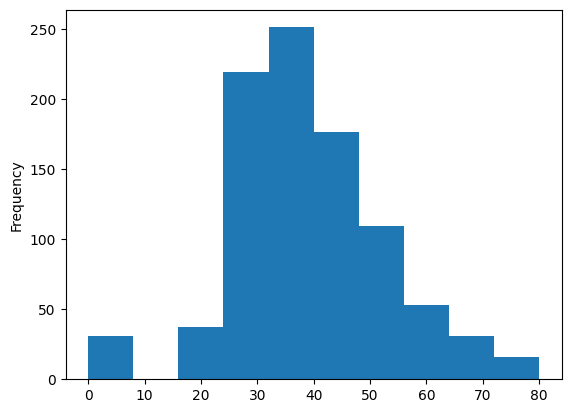

In [66]:
df[df['FraudFound_P'] == 1]['Age'].plot(kind='hist')

In [67]:
df['FraudFound_P'].value_counts()/df.shape[0]*100

FraudFound_P
0    94.013879
1     5.986121
Name: count, dtype: float64

In [68]:
df['WeekOfMonth'].value_counts()

WeekOfMonth
3    3640
2    3557
4    3398
1    3187
5    1637
Name: count, dtype: int64

In [69]:
df['WeekOfMonthClaimed'].value_counts()

WeekOfMonthClaimed
2    3720
3    3583
1    3449
4    3433
5    1234
Name: count, dtype: int64

feature eng

In [70]:
df['WeeksToClaim'] = df['WeekOfMonthClaimed'] - df['WeekOfMonth']

In [71]:
df['WeeksToClaim'].value_counts()

WeeksToClaim
 0    7103
 1    4095
-3     988
 2     864
-4     840
-2     708
-1     515
 3     250
 4      56
Name: count, dtype: int64

In [72]:
df['WeeksToClaim'] = df['WeeksToClaim'].apply(lambda x: x if x >= 0 else x + 4)

In [73]:
df['Days_Policy_Accident'].value_counts()

Days_Policy_Accident
35    15246
0        55
11       55
22       49
5        14
Name: count, dtype: int64

In [74]:
df['Days_Policy_Claim'].value_counts()

Days_Policy_Claim
35    15342
22       56
11       21
Name: count, dtype: int64

In [75]:
df['DayOfWeek'].value_counts()

DayOfWeek
Monday       2615
Friday       2445
Tuesday      2300
Thursday     2173
Wednesday    2159
Saturday     1982
Sunday       1745
Name: count, dtype: int64

In [76]:
df['DayOfWeekClaimed'].value_counts()

DayOfWeekClaimed
Monday       3757
Tuesday      3375
Wednesday    2951
Thursday     2660
Friday       2497
Saturday      127
Sunday         52
Name: count, dtype: int64

In [77]:
df['Is_Weekend'] = df['DayOfWeek'].isin(['Saturday', 'Sunday']).astype(int)

In [78]:
df['Fault'].value_counts()

Fault
Policy Holder    11229
Third Party       4190
Name: count, dtype: int64

In [79]:
df['Suspicious_Report'] = ((df['Fault'] == 'Policy Holder') & (df['PoliceReportFiled'] == 'No')).astype(int)

In [80]:
df['Suspicious_Report'].value_counts()

Suspicious_Report
1    10948
0     4471
Name: count, dtype: int64

feature selection

In [81]:
df.sample(5)

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Price_Numeric,WeeksToClaim,Is_Weekend,Suspicious_Report
6186,Nov,4,Monday,Pontiac,Urban,Monday,Nov,4,Male,Married,...,No,No,External,0,no change,1,24500,0,0,1
14744,Sep,2,Sunday,Honda,Urban,Thursday,Oct,2,Male,Married,...,No,No,External,5,no change,1,75000,0,1,1
8986,Mar,1,Saturday,Mazda,Urban,Monday,Mar,1,Female,Single,...,No,No,External,1,no change,1,24500,0,1,0
4008,Mar,4,Wednesday,Honda,Urban,Monday,Mar,4,Male,Married,...,No,No,External,5,no change,1,24500,0,0,0
2821,Apr,2,Wednesday,Pontiac,Urban,Thursday,Apr,4,Female,Married,...,No,No,External,0,1 year,1,24500,2,0,1


In [82]:
df['High_Risk_Individual'] = (
    (df['Age'] < 25) & 
    (df['DriverRating'] > 2) & 
    (df['PastNumberOfClaims'] != 'none')
).astype(int)

In [83]:
df['Month_Mismatch'] = (df['Month'] != df['MonthClaimed']).astype(int)

In [84]:
df.drop(['Month', 'MonthClaimed'], axis=1, inplace=True)

In [85]:
df['No_Verification_Fraud'] = (
    (df['WitnessPresent'] == 'No') & 
    (df['PoliceReportFiled'] == 'No') & 
    (df['Fault'] == 'Policy Holder')
).astype(int)

In [86]:
y = df['FraudFound_P']

In [87]:
cat_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [88]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

ct = ColumnTransformer([
    ('oe', OrdinalEncoder(), cat_cols)
], remainder='passthrough')

x = df.drop('FraudFound_P', axis=1)
y = df['FraudFound_P']

X = ct.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [89]:
from xgboost import XGBClassifier
# feature selection using XGBoost

model = XGBClassifier()
model.fit(x_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [90]:
model.score(x_test, y_test)

0.9341763942931258

In [91]:
pd.DataFrame(model.feature_importances_, x.columns).sort_values(by=0, ascending=False)

,0
Suspicious_Report,0.389556
Sex,0.148298
MaritalStatus,0.080970
RepNumber,0.074914
Age,0.020044
High_Risk_Individual,0.014477
PastNumberOfClaims,0.013060
Deductible,0.012888
Make,0.011803
Days_Policy_Accident,0.011660


In [92]:
df['Age'].corr(df['AgeOfVehicle'])

np.float64(0.5834280616354276)

In [93]:
import matplotlib.pyplot as plt

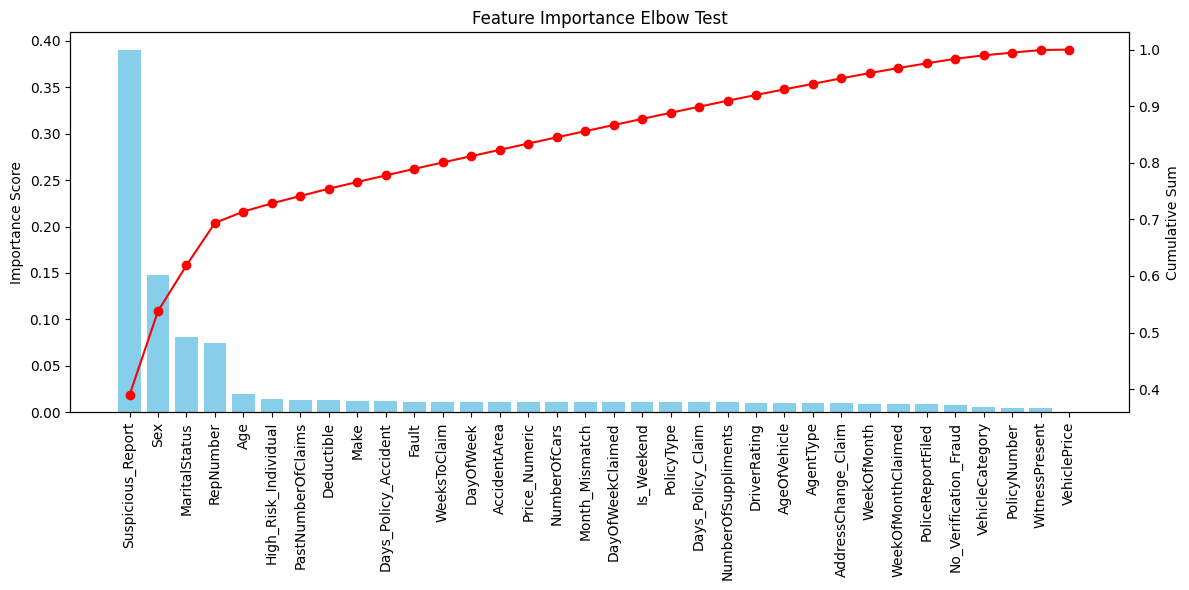

In [94]:
features = pd.DataFrame(model.feature_importances_, x.columns, columns=['importance']).sort_values(by='importance', ascending=False)

features['cum_importance'] = features['importance'].cumsum()
features = features.reset_index().rename(columns={'index': 'feature'})
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(features['feature'], features['importance'], color='skyblue', label='Individual Importance')
ax1.set_ylabel('Importance Score')
plt.xticks(rotation=90)

ax2 = ax1.twinx()
ax2.plot(features['feature'], features['cum_importance'], color='red', marker='o', label='Cumulative Importance')
ax2.set_ylabel('Cumulative Sum')


plt.title('Feature Importance Elbow Test')
fig.tight_layout()
plt.show()



In [95]:
features.head(5)

,feature,importance,cum_importance
0,Suspicious_Report,0.389556,0.389556
1,Sex,0.148298,0.537854
2,MaritalStatus,0.080970,0.618824
3,RepNumber,0.074914,0.693739
4,Age,0.020044,0.713783


df['Suspicious_Report'] = ((df['Fault'] == 'Policy Holder') & (df['PoliceReportFiled'] == 'No')).astype(int) 

df['High_Risk_Individual'] = (
    (df['Age'] < 25) & 
    (df['DriverRating'] > 2) & 
    (df['PastNumberOfClaims'] != 'none')
).astype(int)

In [96]:
features['feature'].head(6).to_list()

['Suspicious_Report',
 'Sex',
 'MaritalStatus',
 'RepNumber',
 'Age',
 'High_Risk_Individual']

In [97]:
df[['Suspicious_Report', 'Sex', 'MaritalStatus', 'RepNumber', 'Age', 'High_Risk_Individual', 'FraudFound_P']]

,Suspicious_Report,Sex,MaritalStatus,RepNumber,Age,High_Risk_Individual,FraudFound_P
0,1,Female,Single,12,21,0,0
1,0,Male,Single,15,34,0,0
2,1,Male,Married,7,47,0,0
3,0,Male,Married,4,65,0,0
4,0,Female,Single,3,27,0,0
...,...,...,...,...,...,...,...
15415,1,Male,Married,5,35,0,1
15416,1,Male,Married,11,30,0,0
15417,1,Male,Single,4,24,1,1
15418,0,Female,Married,6,34,0,0


In [98]:
df = df[['Suspicious_Report', 'Sex', 'MaritalStatus', 'RepNumber', 'Age', 'High_Risk_Individual','FraudFound_P']]
df.head()

,Suspicious_Report,Sex,MaritalStatus,RepNumber,Age,High_Risk_Individual,FraudFound_P
0,1,Female,Single,12,21,0,0
1,0,Male,Single,15,34,0,0
2,1,Male,Married,7,47,0,0
3,0,Male,Married,4,65,0,0
4,0,Female,Single,3,27,0,0


In [99]:
df.isnull().sum()

Suspicious_Report       0
Sex                     0
MaritalStatus           0
RepNumber               0
Age                     0
High_Risk_Individual    0
FraudFound_P            0
dtype: int64

In [100]:
df.duplicated().sum()

np.int64(10662)

In [101]:
df.shape

(15419, 7)

In [102]:
df.drop_duplicates(inplace=True)
df.shape

(4757, 7)

In [103]:
df['FraudFound_P'].value_counts()

FraudFound_P
0    4053
1     704
Name: count, dtype: int64

In [104]:
df.to_csv('important_features_fraud_oracle.csv',index=False)